## Voronoi HBEC


In [3]:
import cv2
import glob
import matplotlib.pyplot as plt
import numpy as np
from natsort import natsorted
import os
import sys
import pandas as pd
from scipy.ndimage import rotate, gaussian_filter
import pickle 
from scipy.stats import circmean, circstd, sem
from skimage.measure import regionprops
from scipy.ndimage import label


sys.path.append('../defect_functions') 
from defect_pairs import * 
from average_flows import * 


ModuleNotFoundError: No module named 'defect_pairs'

In [ ]:


image_list = glob.glob(r"C:\Users\halle\Downloads\C1\*png")
image_list = natsorted(image_list, key=lambda y: y.lower())

n = 5
img1 = cv2.imread(image_list[1])[:,:,0]
img2 = cv2.imread(image_list[2])[:,:,0]
flow = cv2.calcOpticalFlowFarneback(img1,img2, None, 0.5, 3,
    winsize=30, iterations=3, poly_n=5, poly_sigma=1.2, flags=0)


u = flow[..., 0]
v = flow[..., 1]
u = u-u.mean()
v = v-v.mean()

step = 30
x = np.arange(0, flow.shape[1], step, dtype=np.int16)
y = np.arange(0, flow.shape[0], step, dtype=np.int16)


fig, ax1 = plt.subplots(1,1,  figsize=(12,10))
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_clahe = clahe.apply(img1)

ax1.imshow(255-img_clahe, cmap="gray")
ax1.quiver(x,y,
        u[::step, ::step], -v[::step, ::step],
        color="red" , scale=300)

fig, ax2 = plt.subplots(1,1,  figsize=(4,4))
ax2.hist(np.concatenate(v)-np.median(v), 60, alpha=.3, rwidth=.9, density=True, label="v")
ax2.hist(np.concatenate(u)-np.median(u),60, alpha=.8, rwidth=.8, density=True, label="u")
plt.legend(loc='upper right', fontsize=14)


NameError: name 'analyze_defects' is not defined

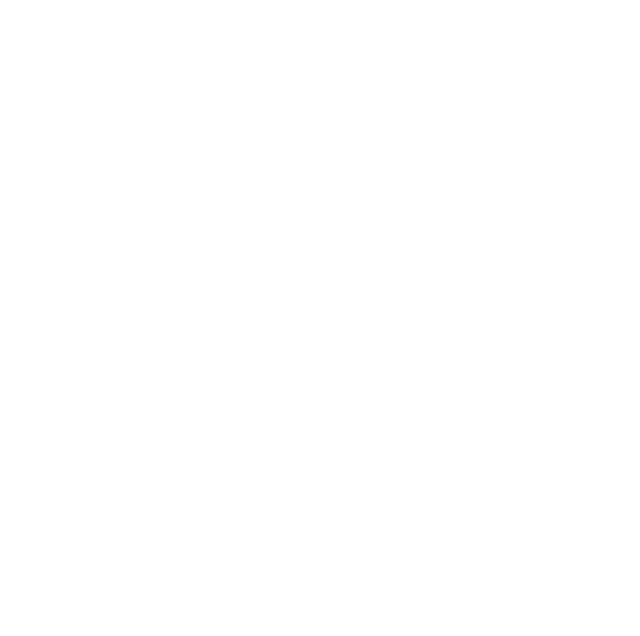

In [2]:
%matplotlib inline
im_num = 1
fig, ax1 = plt.subplots(1,1,  figsize=(8,8))

ax1.clear(); ax1.axis('off') 


imgR = cv2.imread(image_list[im_num])[:,:,0]
y, x = np.mgrid[0:imgR.shape[0], 0:imgR.shape[1]]

sigma = 30
ori, plus, min = analyze_defects(imgR, sigma=sigma)

s = 20
ax1.imshow(np.zeros_like(imgR, dtype=np.float32), cmap="gray")

ax1.quiver(x[::s,::s], y[::s,::s],
    np.cos(ori)[::s,::s], np.sin(ori)[::s,::s], 
    headaxislength=0, headwidth=0, headlength=0, width=.01, 
    color='r', scale=35, pivot='mid', alpha=0.8)
    
plt.gca().set_box_aspect(1)
# fig.savefig(save_folder + "/LR director quiver.svg")